## Importación de librerías y carga del modelo global

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import OrderedDict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import glob
import os
import sys

class PVModel(nn.Module):
    
    def __init__(self, layers_sizes=[256,128,64], input_size=3, dropout=0.1):
        super().__init__()
        
        layers = []
        
        for size in layers_sizes:
            layers.append(nn.Linear(input_size, size)) # Capa lineal
            layers.append(nn.BatchNorm1d(size)) # Batch Normalization
            layers.append(nn.ReLU()) # Activación
            layers.append(nn.Dropout(dropout)) # Dropout
            input_size = size # Actualiza para siguiente capa
        
        layers.append(nn.Linear(input_size, 1))
        
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

# CONFIGURACIÓN
FEATURES = [
    "POA irradiance CMP22 pyranometer (W/m2)",
    "PV module back surface temperature (degC)",
    "T_diff",
    "k_panel",
    "T_correccion",
    "poa_ghi_ratio",
    "dni_ghi_ratio",
    "dhi_ghi_ratio",
    "cloud_index",
    "temp_diff_air",
    "poa_temp",
    "ghi_temp",
]


# 1. Instanciar el modelo vacío
modelo = PVModel(input_size=len(FEATURES), layers_sizes=[256,128,64], dropout=0.1)

# 2. Cargar los pesos guardados por Docker
ruta_npz = "../federated-docker/server/modelos_guardados/modelo_global_final.npz"
pesos_numpy = np.load(ruta_npz)
lista_pesos = [pesos_numpy[arr] for arr in pesos_numpy.files]

# 3. Inyectar pesos en PyTorch
params_dict = zip(modelo.state_dict().keys(), lista_pesos)
state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
modelo.load_state_dict(state_dict, strict=True)

print("Modelo Global Federado cargado correctamente.")

Modelo Global Federado cargado correctamente.


## Preparación de Datos

In [ ]:
DATA_PATH = "../../PV_MaximumPowerPredictor" 

todos_archivos = glob.glob(f"{DATA_PATH}/*.csv")  # Captura todos los *.csv

dfs = []
for archivo in todos_archivos:
    df = pd.read_csv(archivo)
    # Extrae panel_id del nombre del archivo (e.g., Golden_panel1.csv -> Golden_panel1)
    nombre_base = os.path.basename(archivo).replace(".csv", "")
    df["panel_id"] = "_".join(nombre_base.split("_")[1:])  # Adapta según tu naming
    dfs.append(df)

df_todos = pd.concat(dfs, ignore_index=True)
df_todos = df_todos.drop(columns=["Time Stamp (local standard time) yyyy-mm-ddThh:mm:ss"], errors="ignore")
df_todos = df_todos.replace(-9999, np.nan).dropna()

from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(df_todos, test_size=0.2, random_state=42)
train_df, _ = train_test_split(train_val_df, test_size=0.2, random_state=42)

# Constantes Físicas (Sólo Train)
k_por_panel, factor_por_panel = {}, {}
for pid, grupo in train_df.groupby("panel_id"):
    if len(grupo) >= 10:
        G = grupo["POA irradiance CMP22 pyranometer (W/m2)"].values
        T = grupo["PV module back surface temperature (degC)"].values
        P = grupo["Pmp (W)"].values
        y_k, X_k = P / (G + 1e-6), (T - 25).reshape(-1, 1)
        m = LinearRegression().fit(X_k, y_k)
        k_por_panel[pid] = float(-m.coef_[0])
        factor_por_panel[pid] = float(np.mean(P/ (G + 1e-6)))

k_global = np.mean(list(k_por_panel.values())) if k_por_panel else 0.004
factor_global = np.mean(list(factor_por_panel.values())) if factor_por_panel else 0.15

# ============================================================
# Feature Engineering aplicado a TRAIN y TEST
# ============================================================
for df in [train_df, test_df]:
    df["k_panel"] = df["panel_id"].map(k_por_panel).fillna(k_global)
    df["factor_panel"] = df["panel_id"].map(factor_por_panel).fillna(factor_global)
    df["T_correccion"] = (1 - df["k_panel"] * (df["PV module back surface temperature (degC)"] - 25))
    df["physical_model"] = (
        df["POA irradiance CMP22 pyranometer (W/m2)"] * df["factor_panel"] * (1 - df["k_panel"] * (df["PV module back surface temperature (degC)"] - 25))
    )
    df["T_diff"] = df["PV module back surface temperature (degC)"] - 25
    df["poa_ghi_ratio"] = df["POA irradiance CMP22 pyranometer (W/m2)"] / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["dni_ghi_ratio"] = df["Direct normal irradiance (W/m2)"] / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["dhi_ghi_ratio"] = df["Diffuse horizontal irradiance (W/m2)"] / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["cloud_index"] = df["Diffuse horizontal irradiance (W/m2)"] / (df["Direct normal irradiance (W/m2)"] + 1e-6)
    df["temp_diff_air"] = df["PV module back surface temperature (degC)"] - df["Dry bulb temperature (degC)"]
    df["poa_temp"] = df["POA irradiance CMP22 pyranometer (W/m2)"] * df["PV module back surface temperature (degC)"]
    df["ghi_temp"] = df["Global horizontal irradiance (W/m2)"] * df["Dry bulb temperature (degC)"]

# GUARDAR physical_model para guardrail (igual que el cliente)
physical_model_test = test_df["physical_model"].values

# Escalado
x_scaler, y_scaler = StandardScaler(), StandardScaler()
x_scaler.fit(train_df[FEATURES])
y_scaler.fit(train_df["Pmp (W)"].values.reshape(-1, 1))

X_test = x_scaler.transform(test_df[FEATURES])
y_test = y_scaler.transform(test_df["Pmp (W)"].values.reshape(-1, 1))

# Dataloader
from torch.utils.data import TensorDataset, DataLoader
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)), 
    batch_size=256
)
print("Datos de Test procesados y listos.")

Datos de Test procesados y listos.


## Incertidumbre y guardrail

In [22]:
# 6. FUNCIÓN PARA MC DROPOUT (igual que el cliente correcto)
def enable_dropout(model):
    for m in model.modules():
        if m.__class__.__name__.startswith("Dropout"):
            m.train()

# 7. EVALUACIÓN CON MC DROPOUT
modelo.eval()
modelo.apply(enable_dropout)

T = 30  # Número de inferencias estocásticas
test_preds_mc, test_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        batch_preds = [modelo(X_batch) for _ in range(T)]
        test_preds_mc.append(torch.stack(batch_preds))
        test_targets.append(y_batch)

# Procesar resultados
test_preds_mc = torch.cat(test_preds_mc, dim=1).numpy()
test_targets = torch.cat(test_targets).numpy()
predicciones_fisicas = physical_model_test.reshape(-1, 1)

# Desescalar
T_shape, N_shape, _ = test_preds_mc.shape
test_preds_mc_unscaled = y_scaler.inverse_transform(test_preds_mc.reshape(-1, 1)).reshape(T_shape, N_shape, 1)
test_targets_unscaled = y_scaler.inverse_transform(test_targets).flatten()

# 8. CÁLCULO DE INCERTIDUMBRE Y GUARDRAIL
mean_preds = test_preds_mc_unscaled.mean(axis=0).flatten()
std_preds = test_preds_mc_unscaled.std(axis=0).flatten()

UMBRAL_INCERTIDUMBRE = 6.0
test_preds_finales = np.where(std_preds > UMBRAL_INCERTIDUMBRE, 
                             predicciones_fisicas.flatten(), mean_preds)

# 9. MÉTRICAS FINALES
mse_ia = float(((test_targets_unscaled - mean_preds)**2).mean())
mse_fisica = float(((test_targets_unscaled - predicciones_fisicas.flatten())**2).mean())
mse_guardrail = float(((test_targets_unscaled - test_preds_finales)**2).mean())
correlacion = np.corrcoef(std_preds, np.abs(test_targets_unscaled - mean_preds))[0, 1]
activaciones = np.sum(std_preds > UMBRAL_INCERTIDUMBRE)

mejora_pct = ((mse_ia - mse_guardrail) / mse_ia) * 100

print(f"\n{'='*70}")
print(f"RESULTADOS DEL ANÁLISIS DE INCERTIDUMBRE (Parque: {PARQUE})")
print(f"{'='*70}")
print(f"Correlación Incertidumbre-Error: {correlacion:.4f}")
print(f"MSE IA sola                 : {mse_ia:.2f}")
print(f"MSE Fórmula Física          : {mse_fisica:.2f}")
print(f"MSE Híbrido (Guardrail)     : {mse_guardrail:.2f} (Mejora: {mejora_pct:+.2f}%)")
print(f"Activaciones Guardrail      : {activaciones:,} de {len(std_preds):,} ({activaciones/len(std_preds)*100:.1f}%)")
print(f"{'='*70}")


RESULTADOS DEL ANÁLISIS DE INCERTIDUMBRE (Parque: Golden)
Correlación Incertidumbre-Error: 0.7096
MSE IA sola                 : 383.90
MSE Fórmula Física          : 27.46
MSE Híbrido (Guardrail)     : 163.36 (Mejora: +57.45%)
Activaciones Guardrail      : 17,161 de 192,488 (8.9%)


## Visualización

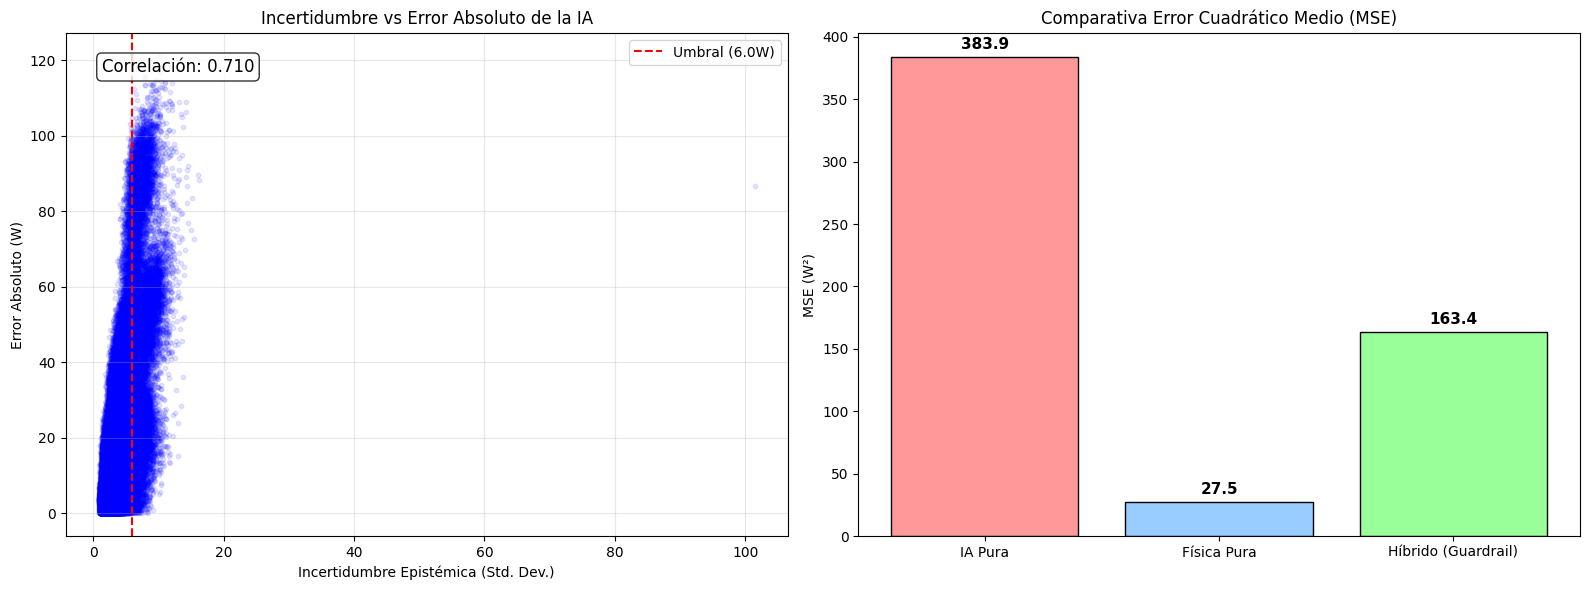

✓ Evaluación completada.


In [23]:
# 10. VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Correlación
axes[0].scatter(std_preds, np.abs(test_targets_unscaled - mean_preds), alpha=0.1, color='blue', s=10)
axes[0].axvline(x=UMBRAL_INCERTIDUMBRE, color='red', linestyle='--', 
                label=f'Umbral ({UMBRAL_INCERTIDUMBRE}W)')
axes[0].set_title("Incertidumbre vs Error Absoluto de la IA")
axes[0].set_xlabel("Incertidumbre Epistémica (Std. Dev.)")
axes[0].set_ylabel("Error Absoluto (W)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].text(0.05, 0.95, f'Correlación: {correlacion:.3f}', 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gráfica 2: Comparativa MSE
nombres = ['IA Pura', 'Física Pura', 'Híbrido (Guardrail)']
valores_mse = [mse_ia, mse_fisica, mse_guardrail]
colores = ['#FF9999', '#99CCFF', '#99FF99']

barras = axes[1].bar(nombres, valores_mse, color=colores, edgecolor='black')
axes[1].set_title("Comparativa Error Cuadrático Medio (MSE)")
axes[1].set_ylabel("MSE (W²)")

for barra in barras:
    yval = barra.get_height()
    axes[1].text(barra.get_x() + barra.get_width()/2, yval + max(valores_mse)*0.01, 
                f'{yval:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Evaluación completada.")